# Task 4.4: FedSAM – Sharpness-Aware Minimization in Federated Learning

In [1]:
# Step 1: Imports and Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import pickle

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- Configuration ---
NUM_CLIENTS = 10
NUM_ROUNDS = 50
LEARNING_RATE = 0.01
BATCH_SIZE = 512
K_FIXED = 5
RHO = 0.05  # SAM neighborhood size
ALPHA_VALUES = [100, 0.2] # IID and non-IID scenarios for comparison
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Running on device: {DEVICE}")

Running on device: cuda


### Step 2: Model and Data Preparation

We use the same CIFAR-10 model and Dirichlet partitioning function to ensure a fair comparison with the FedAvg results from Task 3.

In [2]:
# --- Model Definition for CIFAR-10 ---
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super(CIFAR_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(8 * 8 * 32, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 8 * 8 * 32)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# --- Data Partitioning Function ---
def dirichlet_partition_data(dataset, num_clients, alpha, batch_size):
    num_classes = len(dataset.classes)
    class_indices = [np.where(np.array(dataset.targets) == i)[0] for i in range(num_classes)]
    client_indices = [[] for _ in range(num_clients)]
    for c_indices in class_indices:
        proportions = np.random.dirichlet([alpha] * num_clients)
        num_samples_for_class = (proportions * len(c_indices)).astype(int)
        rem = len(c_indices) - num_samples_for_class.sum()
        for i in range(rem):
            num_samples_for_class[i % num_clients] += 1
        start = 0
        for i in range(num_clients):
            end = start + num_samples_for_class[i]
            client_indices[i].extend(c_indices[start:end])
            start = end
    client_loaders = [DataLoader(Subset(dataset, indices), batch_size=batch_size, shuffle=True) for indices in client_indices]
    return client_loaders

# --- Data Loading and Transformation for CIFAR-10 ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
full_train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

### Step 3: Local Training Implementation for FedSAM

This cell contains the specific training logic for a client using the SAM optimizer.

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from sam.sam import SAM
import inspect

def _toggle_bn_eval(model, on=True):
    bn_states = {}
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            bn_states[m] = m.training
            if on:
                m.eval()
    return bn_states

def _restore_bn(bn_states):
    for m, was_training in bn_states.items():
        m.train(was_training)


def train_client_sam(model, data_loader, lr, local_epochs, rho):
    momentum = 0.9
    weight_decay = 0.0

    # device
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = None
    try:
        base_opt = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
        optimizer = SAM(model.parameters(), base_opt, rho=rho)
    except Exception:
        try:
            optimizer = SAM(model.parameters(), optim.SGD, rho=rho)
            if hasattr(optimizer, "base_optimizer"):
                optimizer.base_optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
            elif hasattr(optimizer, "optimizer"):
                optimizer.optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
            else:
                pass
        except Exception as e:
            raise RuntimeError("Failed to create SAM optimizer wrapper. Inspect installed sam implementation.") from e

    try:
        sig = inspect.signature(optimizer.step)
    except Exception:
        pass
    for epoch in range(local_epochs):
        for batch_idx, (data, target) in enumerate(data_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            def closure():
                bn_states = _toggle_bn_eval(model, on=True)
                optimizer.zero_grad()
                out_adv = model(data)
                loss_adv = criterion(out_adv, target)
                loss_adv.backward()
                _restore_bn(bn_states)
                return loss_adv
            optimizer.step(closure)

    return model.state_dict()


### Step 4: Federated Learning Framework for FedSAM

This function orchestrates the federated training process specifically for FedSAM. It is leaner as it no longer needs the `use_sam` flag.

In [11]:
def get_params_vec(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100 * correct / total

def calculate_divergence(global_model_params_t, local_model_updates):
    divergences = []
    global_vec_cpu = global_model_params_t.cpu()
    for state_dict in local_model_updates:
        local_vec = torch.cat([p.data.view(-1) for p in state_dict.values()]).cpu()
        diff_norm = torch.linalg.norm(global_vec_cpu - local_vec)
        divergences.append(diff_norm.item())
    return np.mean(divergences)

def run_fedsam(num_rounds, local_epochs, client_loaders, model_class, rho):
    print(f"--- Starting FedSAM --- ")
    global_model = model_class().to(DEVICE)
    accuracies, drifts = [], []

    for round_num in range(num_rounds):
        start_time = time.time()
        local_model_updates = []
        global_model_params_t = get_params_vec(global_model).clone().detach()

        for client_idx in range(NUM_CLIENTS):
            if len(client_loaders[client_idx].dataset) == 0: continue
            
            local_model = model_class().to(DEVICE)
            local_model.load_state_dict(global_model.state_dict())
            
            updated_params = train_client_sam(local_model, client_loaders[client_idx], LEARNING_RATE, local_epochs, rho)
            local_model_updates.append(updated_params)
        
        if not local_model_updates: continue

        drift = calculate_divergence(global_model_params_t, local_model_updates)
        drifts.append(drift)

        global_state_dict = global_model.state_dict()
        for key in global_state_dict.keys():
            sum_of_weights = torch.stack([update[key].float() for update in local_model_updates], 0).sum(0)
            global_state_dict[key] = sum_of_weights / len(local_model_updates)
        global_model.load_state_dict(global_state_dict)

        accuracy = evaluate_model(global_model, test_loader)
        accuracies.append(accuracy)
        
        round_time = time.time() - start_time
        print(f"Round {round_num+1}/{num_rounds} | FedSAM | Accuracy: {accuracy:.2f}% | Drift: {drift:.2f} | Time: {round_time:.2f}s")
        
    return accuracies, drifts

### Step 5: Run Experiments and Plot Results

We now execute the full comparison. For each `alpha` value (IID and non-IID), we run FedSAM and load the corresponding FedAvg results from the `task3` directory.

In [16]:
import pickle
import os

results_fedsam = {}

# Create directories for figures and results if they don't exist
os.makedirs('task4_4/figures', exist_ok=True)
os.makedirs('task4_4/results', exist_ok=True)

for alpha in ALPHA_VALUES:
    print(f"\n{'='*50}\nProcessing FedSAM for alpha = {alpha}\n{'='*50}")
    
    fedsam_filename = f'task4_4/results/alpha_{alpha}_FedSAM.pkl'
    
    # --- RUN or LOAD FedSAM experiment ---
    if os.path.exists(fedsam_filename):
        print(f"Loading existing FedSAM results for alpha={alpha}...")
        with open(fedsam_filename, 'rb') as f:
            results_fedsam[alpha] = pickle.load(f)
    else:
        print(f"\nRunning FedSAM experiment for alpha={alpha}...")
        np.random.seed(42) # Ensure data partition is consistent
        client_loaders = dirichlet_partition_data(
            dataset=full_train_dataset, 
            num_clients=NUM_CLIENTS, 
            alpha=alpha, 
            batch_size=BATCH_SIZE
        )
        
        accuracies, drifts = run_fedsam(
            num_rounds=NUM_ROUNDS,
            local_epochs=K_FIXED,
            client_loaders=client_loaders,
            model_class=CIFAR_CNN,
            rho=RHO
        )
        
        results_fedsam[alpha] = {'accuracies': accuracies, 'drifts': drifts}
        print(f"Saving FedSAM results for alpha = {alpha} to {fedsam_filename}")
        with open(fedsam_filename, 'wb') as f:
            pickle.dump(results_fedsam[alpha], f)



Processing FedSAM for alpha = 100

Running FedSAM experiment for alpha=100...
--- Starting FedSAM --- 
Round 1/50 | FedSAM | Accuracy: 31.19% | Drift: 0.96 | Time: 59.07s
Round 2/50 | FedSAM | Accuracy: 40.57% | Drift: 1.01 | Time: 59.92s
Round 3/50 | FedSAM | Accuracy: 45.53% | Drift: 0.90 | Time: 59.73s
Round 4/50 | FedSAM | Accuracy: 48.24% | Drift: 0.82 | Time: 60.14s
Round 5/50 | FedSAM | Accuracy: 50.71% | Drift: 0.80 | Time: 60.40s
Round 6/50 | FedSAM | Accuracy: 52.77% | Drift: 0.80 | Time: 59.01s
Round 7/50 | FedSAM | Accuracy: 54.37% | Drift: 0.82 | Time: 60.43s
Round 8/50 | FedSAM | Accuracy: 56.26% | Drift: 0.84 | Time: 60.23s
Round 9/50 | FedSAM | Accuracy: 58.06% | Drift: 0.88 | Time: 60.21s
Round 10/50 | FedSAM | Accuracy: 59.27% | Drift: 0.90 | Time: 57.36s
Round 11/50 | FedSAM | Accuracy: 60.31% | Drift: 0.92 | Time: 58.80s
Round 12/50 | FedSAM | Accuracy: 61.82% | Drift: 0.95 | Time: 60.18s
Round 13/50 | FedSAM | Accuracy: 62.38% | Drift: 0.98 | Time: 60.00s
Round 14

In [7]:
import sam
import inspect
print(inspect.signature(sam.SAM.__init__))

(self, params: Iterable[torch.Tensor], optim: torch.optim.optimizer.Optimizer, rho: float = 0.05)


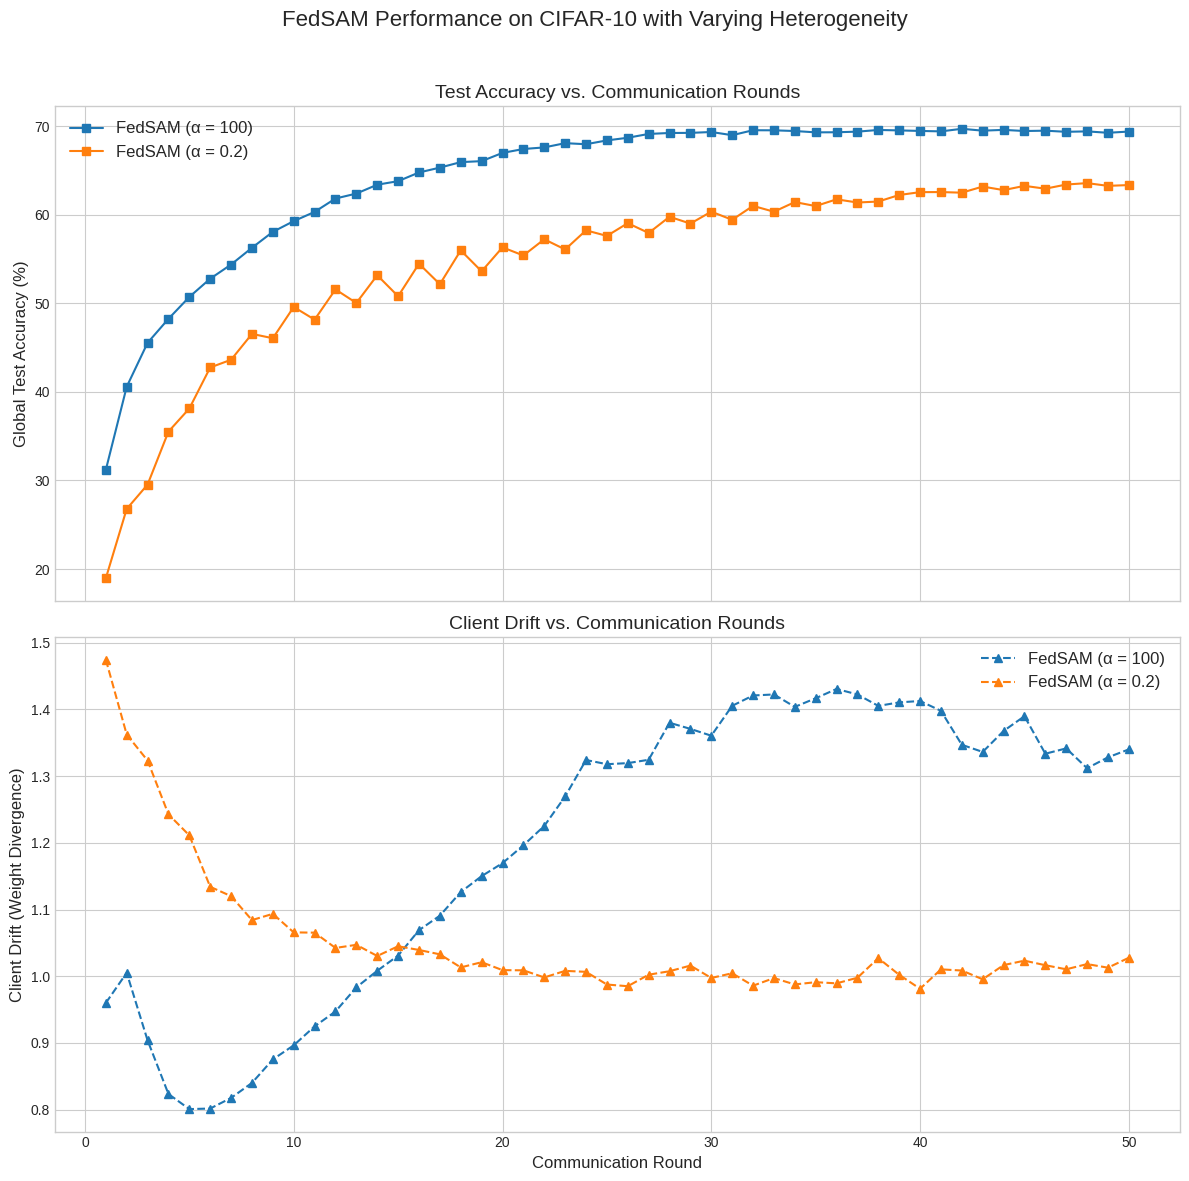

In [17]:
# --- Plotting --- 
plt.style.use('seaborn-v0_8-whitegrid')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
fig.suptitle('FedSAM Performance on CIFAR-10 with Varying Heterogeneity', fontsize=16)

# Accuracy Plot
for alpha, result in results_fedsam.items():
    ax1.plot(range(1, NUM_ROUNDS + 1), result['accuracies'], marker='s', linestyle='-', label=f'FedSAM (α = {alpha})')
ax1.set_ylabel("Global Test Accuracy (%)", fontsize=12)
ax1.set_title("Test Accuracy vs. Communication Rounds", fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True)

# Drift Plot
for alpha, result in results_fedsam.items():
    ax2.plot(range(1, NUM_ROUNDS + 1), result['drifts'], marker='^', linestyle='--', label=f'FedSAM (α = {alpha})')
ax2.set_xlabel("Communication Round", fontsize=12)
ax2.set_ylabel("Client Drift (Weight Divergence)", fontsize=12)
ax2.set_title("Client Drift vs. Communication Rounds", fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'task4_4/figures/fedsam_performance_by_alpha.png')
plt.show()